In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("Pandas version:", pd.__version__)
print("Analytics environment is ready.")

Matplotlib is building the font cache; this may take a moment.


Pandas version: 2.3.3
Analytics environment is ready.


# Wellness Services Exploratory Data Analysis

# Wellness Services Exploratory Data Analysis

In [30]:
from pathlib import Path;
print(Path.cwd())

/Users/refiloematlapeng/Desktop/pulse80/data-analytics/notebooks/eda/services


In [31]:
RAW_DATA_DIR = Path.cwd().parents[2] / "data" / "raw"; print(RAW_DATA_DIR); print("Folder exists:", RAW_DATA_DIR.exists())

/Users/refiloematlapeng/Desktop/pulse80/data-analytics/data/raw
Folder exists: True


In [32]:
print([file.name for file in sorted(RAW_DATA_DIR.glob("*.csv"))])

['Participations.csv', 'Programme_Services.csv', 'Programmes.csv', 'Screenings.csv', 'Services.csv']


In [33]:
services = pd.read_csv(RAW_DATA_DIR / "Services.csv"); programmes = pd.read_csv(RAW_DATA_DIR / "Programmes.csv"); programme_services = pd.read_csv(RAW_DATA_DIR / "Programme_Services.csv"); screenings = pd.read_csv(RAW_DATA_DIR / "Screenings.csv"); participations = pd.read_csv(RAW_DATA_DIR / "Participations.csv"); print("All five CSV files loaded successfully.")

All five CSV files loaded successfully.


In [34]:
print("Services:", services.shape); print("Programmes:", programmes.shape); print("Programme Services:", programme_services.shape); print("Screenings:", screenings.shape); print("Participations:", participations.shape)

Services: (6, 6)
Programmes: (1, 11)
Programme Services: (6, 5)
Screenings: (144, 8)
Participations: (28, 9)


## 1. Initial Service Data Inspection

In [35]:
services

,service_id,code,name,category,default_unit,active
0,SRV-BP,blood_pressure,Blood Pressure Screening,screening,mmHg,True
1,SRV-BMI,bmi,BMI Assessment,screening,kg/m2,True
2,SRV-GLU,glucose,Blood Glucose Screening,screening,mmol/L,True
3,SRV-CHOL,cholesterol,Cholesterol Screening,screening,mmol/L,True
4,SRV-STR,stress,Stress Screening,screening,score,True
5,SRV-FIT,fitness,Fitness Assessment,fitness,score,True


In [36]:
services.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   service_id    6 non-null      object
 1   code          6 non-null      object
 2   name          6 non-null      object
 3   category      6 non-null      object
 4   default_unit  6 non-null      object
 5   active        6 non-null      bool  
dtypes: bool(1), object(5)
memory usage: 374.0+ bytes


## 2. Missing Value Analysis

In [37]:
services.isna().sum().to_frame(name="missing_count")

,missing_count
service_id,0
code,0
name,0
category,0
default_unit,0
active,0


## 3. Service Identifier Quality

In [38]:
print("Duplicate service IDs:", services["service_id"].duplicated().sum()); print("Duplicate service codes:", services["code"].duplicated().sum()); print("Unique service IDs:", services["service_id"].nunique()); print("Unique service codes:", services["code"].nunique())

Duplicate service IDs: 0
Duplicate service codes: 0
Unique service IDs: 6
Unique service codes: 6


In [39]:
assert services["service_id"].notna().all(); assert services["service_id"].is_unique; assert services["code"].notna().all(); assert services["code"].is_unique; print("Identifier validation passed.")

Identifier validation passed.


### Identifier Format Validation

In [40]:
invalid_service_ids = services[~services["service_id"].str.match(r"^SRV-[A-Z0-9]+$", na=False)]; invalid_service_codes = services[~services["code"].str.match(r"^[a-z][a-z0-9_]*$", na=False)]; print("Invalid service IDs:", len(invalid_service_ids)); print("Invalid service codes:", len(invalid_service_codes))

Invalid service IDs: 0
Invalid service codes: 0


In [41]:
assert invalid_service_ids.empty; assert invalid_service_codes.empty; print("Identifier formats are consistent.")

Identifier formats are consistent.


## 4. Service Definitions and Categories

In [42]:
services[["service_id", "code", "name", "category", "default_unit", "active"]]

,service_id,code,name,category,default_unit,active
0,SRV-BP,blood_pressure,Blood Pressure Screening,screening,mmHg,True
1,SRV-BMI,bmi,BMI Assessment,screening,kg/m2,True
2,SRV-GLU,glucose,Blood Glucose Screening,screening,mmol/L,True
3,SRV-CHOL,cholesterol,Cholesterol Screening,screening,mmol/L,True
4,SRV-STR,stress,Stress Screening,screening,score,True
5,SRV-FIT,fitness,Fitness Assessment,fitness,score,True


In [43]:
services["category"].value_counts().to_frame(name="service_count")

,service_count
category,
screening,5
fitness,1


In [44]:
services["default_unit"].value_counts().to_frame(name="service_count")

,service_count
default_unit,
score,2
mmol/L,2
kg/m2,1
mmHg,1


### Service Category Distribution

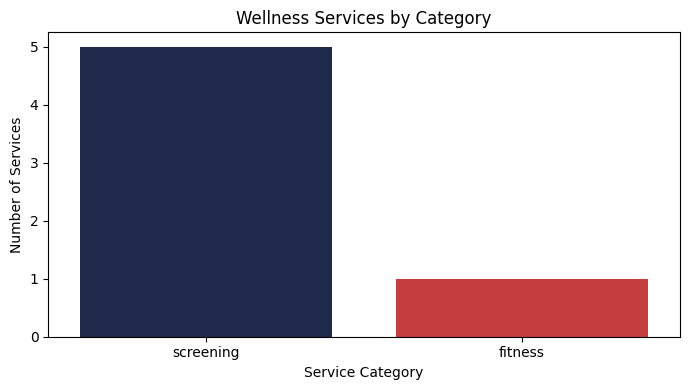

In [46]:
plt.figure(figsize=(7, 4)); sns.countplot(data=services, x="category", order=services["category"].value_counts().index, hue="category", palette={"screening": "#172554", "fitness": "#DC2626"}, legend=False); plt.title("Wellness Services by Category"); plt.xlabel("Service Category"); plt.ylabel("Number of Services"); plt.tight_layout(); plt.show()

## 5. Programme-Service Relationship Validation

In [47]:
programme_services

,programme_service_id,programme_id,service_id,target_capacity,display_order
0,PS-001,PRG-001,SRV-BP,28,1
1,PS-002,PRG-001,SRV-BMI,28,2
2,PS-003,PRG-001,SRV-GLU,28,3
3,PS-004,PRG-001,SRV-CHOL,28,4
4,PS-005,PRG-001,SRV-STR,28,5
5,PS-006,PRG-001,SRV-FIT,28,6


In [48]:
orphan_service_ids = sorted(set(programme_services["service_id"]) - set(services["service_id"])); print("Service IDs not found in Services.csv:", orphan_service_ids)

Service IDs not found in Services.csv: []


In [49]:
orphan_programme_ids = sorted(set(programme_services["programme_id"]) - set(programmes["programme_id"])); print("Programme IDs not found in Programmes.csv:", orphan_programme_ids)

Programme IDs not found in Programmes.csv: []


In [50]:
assert not orphan_service_ids; assert not orphan_programme_ids; assert programme_services["programme_service_id"].is_unique; assert not programme_services.duplicated(subset=["programme_id", "service_id"]).any(); print("Programme-service relationship validation passed.")

Programme-service relationship validation passed.
